# Supporting XGBoost Material

## [Tidy Tuesday Spotify Dataset](https://github.com/rfordatascience/tidytuesday/tree/main/data/2020/2020-01-21)

Author: [Ashley Kennedy](ashley.g.kennedy@gmail.com)

## Import Modules and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from xgboost.callback import EarlyStopping
from xgboost import plot_importance

In [3]:
spotify_copy = pd.read_csv('spotify_copy.csv')

In [4]:
X = spotify_copy[[
    'playlist_genre',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'instrumentalness',
    'valence',
    'tempo',
    'duration_ms',
    'release_month',
    'log_speechiness',
    'sqrt_liveness',
    'bin_year',
    'logit_acousticness'
]]

X = pd.get_dummies(X, drop_first=True)

In [5]:
y = spotify_copy['y']

### Create the train and test splits.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=121
)

### Fit an XGBoost Regressor Model

Do decide which parameters to use, I will create lists with different values and use `RandomizedSearchCV` to iterate across all parameters to find the best ones for making predictions.

In [7]:
param_grid = {
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [8]:
from sklearn.model_selection import RandomizedSearchCV

rs = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='r2',
    cv=3,
    random_state=121
)

rs.fit(X_train, y_train)
print(rs.best_params_)

{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


According to the randomized search, the best parameters are `subsample=0.8`, `n_estimators=500`, `max_dept=7`, `learning_rate=0.05`, and `colsample_bytree=1.0`.

Fit the XGBoost regressor model using `.XGBRegressor()`.

In [9]:
mod_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=121
)

In [10]:
mod_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### Model Accuracy on the Train Set

In [11]:
train_preds = mod_xgb.predict(X_train)

In [12]:
print(r2_score(y_train, train_preds))
print(mean_squared_error(y_train, train_preds))

0.688017271782025
1.511424368980984


In [13]:
test_preds = mod_xgb.predict(X_test)

In [14]:
print(r2_score(y_test, test_preds))
print(mean_squared_error(y_test, test_preds))

0.14115704698719478
4.184305275973321


As we can see by the R-squared values, XGBoost has overfitted the model. Because of this, convert my data into a DMatrix and implement early stopping.

In [15]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [16]:
dparams = {
    'objective': 'reg:squarederror',
    'eta': 0.05,
    # I will use shallower trees to help prevent overfitting
    'max_depth': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'rmse'
}

In [17]:
mod_xgb_2 = xgb.train(
    params=dparams,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    early_stopping_rounds=50
)

[0]	train-rmse:2.19484	eval-rmse:2.20195
[1]	train-rmse:2.18956	eval-rmse:2.19755
[2]	train-rmse:2.18474	eval-rmse:2.19356
[3]	train-rmse:2.17985	eval-rmse:2.18876
[4]	train-rmse:2.17519	eval-rmse:2.18469
[5]	train-rmse:2.17089	eval-rmse:2.18071
[6]	train-rmse:2.16632	eval-rmse:2.17689
[7]	train-rmse:2.16232	eval-rmse:2.17329
[8]	train-rmse:2.15872	eval-rmse:2.17042
[9]	train-rmse:2.15547	eval-rmse:2.16756
[10]	train-rmse:2.15227	eval-rmse:2.16486
[11]	train-rmse:2.14915	eval-rmse:2.16209
[12]	train-rmse:2.14628	eval-rmse:2.15977
[13]	train-rmse:2.14362	eval-rmse:2.15747
[14]	train-rmse:2.14115	eval-rmse:2.15567
[15]	train-rmse:2.13871	eval-rmse:2.15366
[16]	train-rmse:2.13641	eval-rmse:2.15186
[17]	train-rmse:2.13403	eval-rmse:2.15011
[18]	train-rmse:2.13188	eval-rmse:2.14827
[19]	train-rmse:2.13005	eval-rmse:2.14693
[20]	train-rmse:2.12827	eval-rmse:2.14574
[21]	train-rmse:2.12652	eval-rmse:2.14422
[22]	train-rmse:2.12483	eval-rmse:2.14272
[23]	train-rmse:2.12305	eval-rmse:2.14135
[2

In [18]:
dtrain_preds = mod_xgb_2.predict(dtrain)

In [19]:
print(r2_score(y_train, dtrain_preds))
print(mean_squared_error(y_train, dtrain_preds))

0.18781145396569787
3.9347100004389004


In [20]:
dtest_preds = mod_xgb_2.predict(dtest)

In [21]:
print(r2_score(y_test, dtest_preds))
print(mean_squared_error(y_test, dtest_preds))

0.10832531316645466
4.344262339792213


Visualize the importance of each feature.

<Figure size 640x480 with 0 Axes>

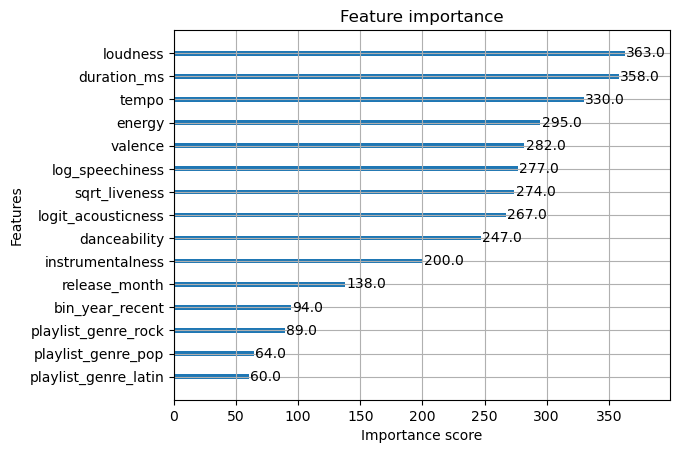

In [22]:
plt.figure()

plot_importance(mod_xgb_2, max_num_features=15)

plt.show()

XGBoost identifies continuous audio features as the primary drivers of popularity while the categorical variables contribute far less. This aligns with my EDA findings and cluster analysis. This pattern is consistent with the EDA and cluster results which showed that audio characteristics carry the most influence on the output `y`.

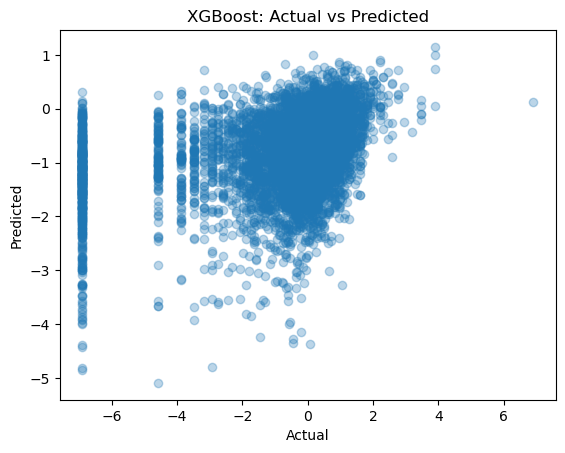

In [23]:
fig, ax = plt.subplots()

plt.scatter(y_test, dtest_preds, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

The XGBoost model captures broad trends in the data but shows substantial scatter around the diagonal, indicating limited predictive accuracy. This is expected given the noisy nature of the popularity outcome: even with nonlinear modeling, audio features explain only a modest portion of the variation in `y`.

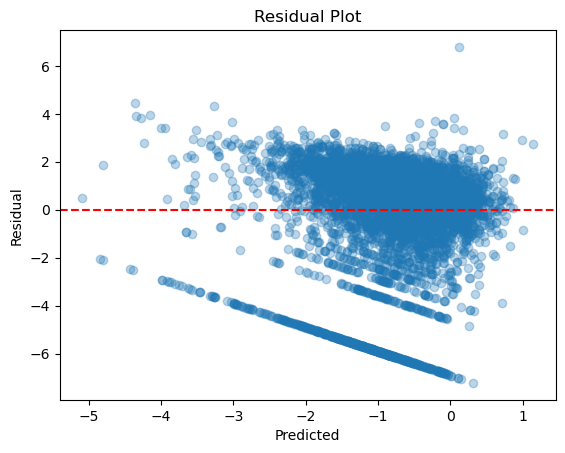

In [24]:
resid = y_test - dtest_preds

fig, ax = plt.subplots()

# scatter plot of dtest_preds vs residuals
plt.scatter(dtest_preds, resid, alpha=0.3)

# plot a line at 0 to represent residuals
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

Residuals are centered around zero but show a wide spread across prediction values, confirming that the model has difficulty capturing the full complexity of popularity.

### Cross-Validation

In [25]:
xgb_cv = xgb.cv(
    params=dparams,
    dtrain=dtrain,
    num_boost_round=500,
    nfold=5,
    early_stopping_rounds=50,
    metrics='rmse',
    seed=121,
    verbose_eval=False
)

In [26]:
xgb_cv

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,2.194444,0.009804,2.194527,0.039266
1,2.189201,0.009857,2.189705,0.039344
2,2.184364,0.009957,2.185088,0.039331
3,2.179252,0.009911,2.180192,0.039352
4,2.174561,0.009882,2.175701,0.039322
...,...,...,...,...
495,1.969360,0.009057,2.061782,0.036412
496,1.969184,0.009063,2.061824,0.036414
497,1.968995,0.009077,2.061851,0.036352
498,1.968837,0.009096,2.061864,0.036307


In [27]:
xgb_cv.shape[0]

500

Cross-validation did not trigger early stopping, indicating that validation RMSE continued to improve throughout all 500 boosting rounds. Therefore, the best iteration selected by XGBoost was the final round (500), which was used to train the final model.

I will now visualize my cross-validation results in a stripplot.

In [28]:
cv_long = xgb_cv.reset_index().\
    rename(columns={'index': 'iteration'}).\
        melt(id_vars='iteration',
             value_vars=['train-rmse-mean', 'test-rmse-mean'],
             var_name='from_set',
             value_name='rmse')

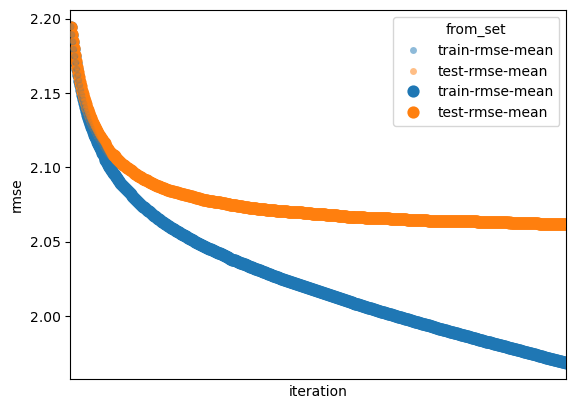

In [29]:
fig, ax = plt.subplots()

sns.stripplot(data=cv_long, x='iteration', y='rmse', hue='from_set', alpha=0.5, ax=ax)

sns.pointplot(data=cv_long, x='iteration', y='rmse', hue='from_set', linestyles='none', ax=ax)

ax.set_xticks([])

plt.show()

The CV curves show that both training and validation RMSE decrease and stabilize over time. The small gap between the curves indicates limited overfitting, and the model continued improving up to the full 500 rounds.

### Conclusion

The initial XGBoost model showed strong overfitting, with the train split showing an R-squared around 0.68, but the test split R-squared only 0.14. After applying regularization (reduced max_depth, subsampling, column sampling, and L2 penalty), the model generalized much better: the train R-squared dropped to 0.18 and the test R-squared was 0.11. Although the overall predictive power remains limited, this is expected given the noisy nature of popularity, and the regularized model provides a more reliable estimate of the explainable variation in the data.